# EO-SAR Binary Change Detection - Preprocessing

This covers data cleaning, normalization, and the creation of a PyTorch Dataset class for training.

In [1]:
import sys
!{sys.executable} -m pip uninstall torch torchvision torchaudio -y
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached https://download-r2.pytorch.org/whl/cu128/torch-2.11.0%2Bcu128-cp310-cp310-win_amd64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cu128/torchvision-0.26.0%2Bcu128-cp310-cp310-win_amd64.whl.metadata (5.6 kB)
  Using cached https://download-r2.pytorch.org/whl/cu128/torchaudio-2.11.0%2Bcu128-cp310-cp310-win_amd64.whl.metadata (7.0 kB)
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 6.7 MB/s eta 0:06:50
   ---------------------------------------- 0.0/2.8 GB 7.2 MB/s eta 0:06:23
   ---------------------------------------- 0.0/2.8 GB 7.3 MB/s eta 0:06:19
   ---------------------------------------- 0.0/2.8 GB 8.0 MB/s eta 0:05:45
   ---------------------------------------- 0.0/2.8 GB 6.0 MB/s eta 0:07:41
   ---------------------------------------- 0.0/2.8 GB 5.5 MB/s eta 0:08:18
   -------------------------------------

In [13]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import tifffile as tiff
from pathlib import Path
import torchvision.transforms as T
import matplotlib.pyplot as plt

class EOSARDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir) / split
        self.pre_dir = self.root_dir / 'pre-event'
        self.post_dir = self.root_dir / 'post-event'
        self.target_dir = self.root_dir / 'target'
        
        self.filenames = sorted([f.name for f in self.pre_dir.glob('*.tif')])
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        
        pre_img = tiff.imread(self.pre_dir / fname).astype(np.float32)
        post_img = tiff.imread(self.post_dir / fname).astype(np.float32)
        
        # Check for target (might not exist for test split)
        target_path = self.target_dir / fname
        if target_path.exists():
            target = tiff.imread(target_path).astype(np.float32)
            # Normalize target to [0, 1] if it's 0-255
            if target.max() > 1:
                target = target / 255.0
        else:
            target = np.zeros_like(pre_img[..., 0]) # Dummy target

        # Simple Preprocessing: Normalization
        # Example: Min-Max Scaling per channel
        pre_img = self.normalize(pre_img)
        post_img = self.normalize(post_img)

        # Convert to Tensors (C, H, W)
        pre_tensor = torch.from_numpy(pre_img).permute(2, 0, 1) if len(pre_img.shape) == 3 else torch.from_numpy(pre_img).unsqueeze(0)
        post_tensor = torch.from_numpy(post_img).permute(2, 0, 1) if len(post_img.shape) == 3 else torch.from_numpy(post_img).unsqueeze(0)
        target_tensor = torch.from_numpy(target).unsqueeze(0)

        if self.transform:
            # For segmentation, we need to apply same transforms to image and mask
            # This is a simple implementation, for production use Albumentations
            combined = torch.cat([pre_tensor, post_tensor, target_tensor], dim=0)
            combined = self.transform(combined)
            pre_tensor = combined[:pre_tensor.shape[0]]
            post_tensor = combined[pre_tensor.shape[0]:pre_tensor.shape[0]+post_tensor.shape[0]]
            target_tensor = combined[-1:]

        return pre_tensor, post_tensor, target_tensor

    def normalize(self, img):
        # Basic normalization to [0, 1]
        img_min, img_max = img.min(), img.max()
        if img_max - img_min > 0:
            return (img - img_min) / (img_max - img_min)
        return img

## 1. Test the Dataset and DataLoader

In [14]:
import sys
import os
# Add root to path so we can import src module
sys.path.append(os.path.abspath('..'))

from src.data.dataset import EOSARDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Initialize the Modular Dataset
dataset_root = '../dataset'
train_dataset = EOSARDataset(root_dir=dataset_root, split='train', patch_size=256, augment=True)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)

print(f"Initialized Training Dataset with {len(train_dataset)} images.")
print(f"DataLoader created with {len(train_loader)} batches (Batch Size: 8).")


Initialized Training Dataset with 2781 images.
DataLoader created with 348 batches (Batch Size: 8).


EO Batch Shape: torch.Size([8, 3, 256, 256])


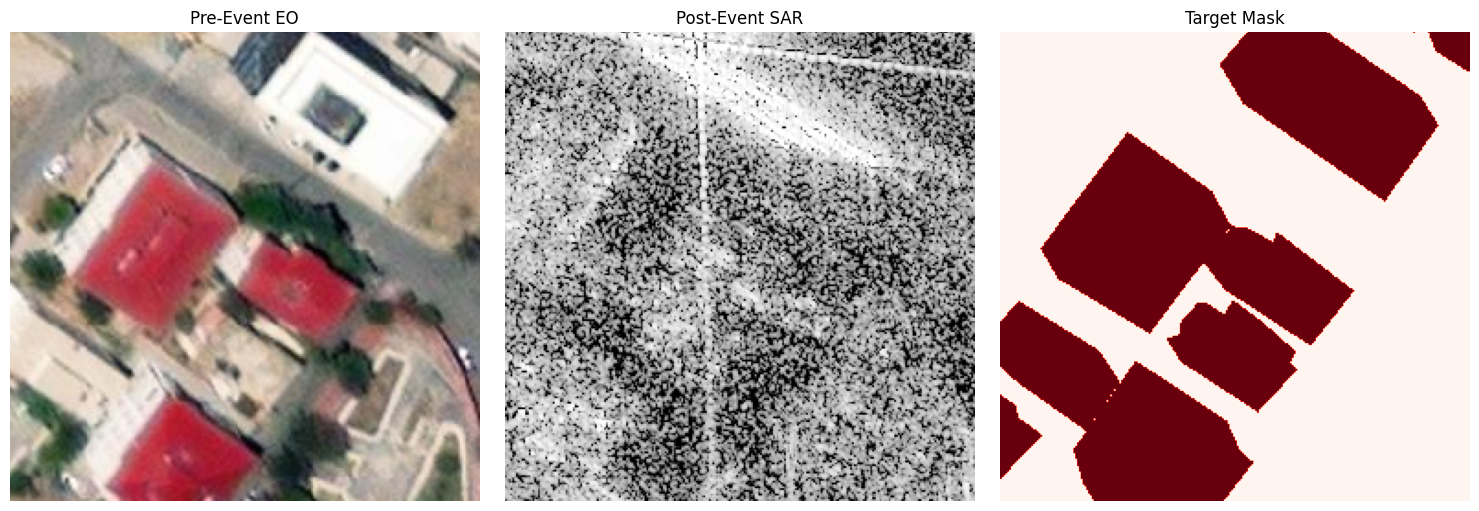

In [15]:
def visualize_triplet(eo, sar, mask, idx=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    eo_img = eo[idx].permute(1, 2, 0).numpy()
    axes[0].imshow(eo_img)
    axes[0].set_title("Pre-Event EO")
    axes[0].axis('off')
    
    sar_img = sar[idx].squeeze(0).numpy()
    axes[1].imshow(sar_img, cmap='gray')
    axes[1].set_title("Post-Event SAR")
    axes[1].axis('off')
    
    mask_img = mask[idx].squeeze(0).numpy()
    axes[2].imshow(mask_img, cmap='Reds')
    axes[2].set_title("Target Mask")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

try:
    # Fetch a single batch and visualize it
    eo_batch, sar_batch, mask_batch = next(iter(train_loader))
    print(f"EO Batch Shape: {eo_batch.shape}")
    visualize_triplet(eo_batch, sar_batch, mask_batch, idx=0)
except StopIteration:
    print("Warning: Dataset is empty. Make sure dataset folder is populated.")
